In [11]:
# import libraries

import pandas as pd
import numpy as np
from sklearn.manifold import TSNE 
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

In [12]:
# read data
iris = pd.read_csv("iris.txt", sep = ' ', header = None)
images = pd.read_csv("images.txt", header = None)


In [13]:
images.head()

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
iris.head()

,0,1,2,3
0,5.7,4.4,1.5,0.4
1,5.5,4.2,1.4,0.2
2,5.2,4.1,1.5,0.1
3,5.8,4.0,1.2,0.2
4,5.4,3.9,1.7,0.4


In [49]:
# Normalize and dimensionality reduction

def preProcess(data):
    
    # normalize data
    normalized_data = normalize(data, axis=1, norm='l2')
    
    # perform dimensionality reduction on the normalized data and return the reduced data
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=800)
    reduced_data = tsne.fit_transform(normalized_data)

    return reduced_data

In [50]:
data_images = preProcess(images)
data_iris = preProcess(iris)

In [51]:
print(data_images)
print(len(data_images))

[[-18.30051   45.643543]
 [ 15.966711  43.393673]
 [ 26.564842  58.544548]
 ...
 [ 24.021826 -58.35199 ]
 [-44.778957 -41.390034]
 [-45.773083  46.10616 ]]
10740


In [52]:
print(data_iris)
print(len(data_iris))

[[ 1.65703926e+01  1.57807469e+00]
 [ 1.65560265e+01  1.36230755e+00]
 [ 1.63090172e+01  2.09088111e+00]
 [ 1.78270721e+01 -1.43417940e-01]
 [ 1.81101322e+01  3.26055479e+00]
 [ 1.71493263e+01  7.82151818e-01]
 [-5.88809013e+00 -4.05716515e+00]
 [-6.41944361e+00 -9.80668306e-01]
 [ 1.84211540e+01  4.34113455e+00]
 [ 1.99362679e+01  2.20123458e+00]
 [ 1.72893238e+01  2.84543324e+00]
 [ 1.72065029e+01  2.35005283e+00]
 [ 1.77572308e+01  2.78627563e+00]
 [ 1.89575653e+01  1.27268302e+00]
 [ 1.85033245e+01  1.71530020e+00]
 [-5.54389763e+00 -5.96117020e+00]
 [ 1.77703056e+01  1.70807874e+00]
 [ 1.63068104e+01  8.73900890e-01]
 [ 1.96757679e+01  4.47632456e+00]
 [ 1.95763550e+01  1.61077821e+00]
 [ 1.85914154e+01  1.44230211e+00]
 [ 1.88271503e+01  1.14120817e+00]
 [ 1.79286213e+01  1.04907262e+00]
 [ 1.98353710e+01 -7.03934059e-02]
 [-6.04668617e+00 -6.90887833e+00]
 [-6.09200525e+00 -6.95560265e+00]
 [-5.84880733e+00  2.56675386e+00]
 [ 1.88791180e+01  4.57450724e+00]
 [ 2.12560482e+01  2

In [304]:
# Implement the KMeans clustering 

class KMeans:
    
    def __init__(self, k=3, return_sse = False):
        self.k = k
        self.return_sse = return_sse 
        
    def fit_predict(self, data):
        self.data = data
        
        # Initialize the centroids 
        self.centroids = self.initialize_centroids()
        print(self.centroids)
        
        
        while True:
            
            ''' After initializing the centroids, calculate the distance of each sample/row to the centroids
                For every row/sample you should get three distances, one for each centroid'''
            
            
            distances = self.distances()
            
  
            # Assign each data point to the cluster represented by the index of its nearest centroid.
            
            
            self.cluster_indices = np.argmin(distances, axis = 1)
  
            # Determine the index of the centroid with the minimum distance.
           
            self.old_centroids = self.centroids.copy()
            
            
            # Update each centroid by computing the mean of the data points assigned to its cluster.
            for i in range(self.k):
                
                points_in_cluster = self.data[self.cluster_indices == i]
                
                if len(points_in_cluster) > 0:
                    self.centroids[i] = np.mean(points_in_cluster, axis=0)
    
            
                #self.centroids[i] = # mean of the data points in cluster i
             
            ''' Compare whether the old centroids and newly computed centroids are equal, 
            if they are equal terminate the algorithm '''
            # compare here
            if np.array_equal(self.old_centroids, self.centroids):
                break
  
        
        if self.return_sse:
            sse = self.compute_sse()

            return sse
        
        self.cluster_indices += 1
        return self.cluster_indices
    

    
    # This method initializes the centroids
    def initialize_centroids(self):
        np.random.seed(42)
        centroids = np.random.uniform(low=np.amin(self.data, axis=0), high=np.amax(self.data, axis=0), size=(self.k, self.data.shape[1]))
        
        return centroids

    
    
    # This method calculates the distance
    def distances(self):
        
        distances = []
        
        for datapoint in self.data:
        # caulcuate distance using self.data and self.centroids
            distances.append(np.sqrt(np.sum((self.centroids - datapoint)**2, axis = 1)))
        distances = np.array(distances)
        
        return distances
     
    
    # Compute SSE (Sum of Squared Errors) (Use can implement any objective function of your choice)
    def compute_sse(self):
        sse = 0
        for i in range(self.k):
            clusterpoints = self.data[self.cluster_indices == i]
            squared_distances = np.sum((clusterpoints - self.centroids[i]) ** 2)
            sse += squared_distances
        # compute sse using self.data, self.cluster_indices, self.k (refer to the formula mentioned in KMeans slides)
        return sse


In [316]:
def plot_sse(sse, K):
    plt.figure(figsize=(10, 6)) 
    plt.plot(K, sse, marker='o', linestyle='-', color='purple') 
    plt.title('SSE vs. Number of Clusters') 
    plt.xlabel('Number of Clusters (K)')  
    plt.ylabel('Sum of Squared Errors (SSE)')
    plt.xticks(K)
    plt.grid(True) 
    plt.show()
    
    # plot of objective function (y-axis) vs. value of K increasing from 2 to 20 in steps of 2 (x-axis)

# Objective function vs K for Iris

[[1.36172719 4.85638285]]
[[ 1.36172719  4.85638285]
 [13.65075854  0.36066745]]
[[ 1.36172719  4.85638285]
 [13.65075854  0.36066745]
 [-6.15089997 -5.29210429]]
[[ 1.36172719  4.85638285]
 [13.65075854  0.36066745]
 [-6.15089997 -5.29210429]
 [-9.51784293  3.77683953]]
[[ 1.36172719  4.85638285]
 [13.65075854  0.36066745]
 [-6.15089997 -5.29210429]
 [-9.51784293  3.77683953]
 [ 9.15122553  1.75787379]]
[[  1.36172719   4.85638285]
 [ 13.65075854   0.36066745]
 [ -6.15089997  -5.29210429]
 [ -9.51784293   3.77683953]
 [  9.15122553   1.75787379]
 [-10.80703836   5.10150793]]
[[  1.36172719   4.85638285]
 [ 13.65075854   0.36066745]
 [ -6.15089997  -5.29210429]
 [ -9.51784293   3.77683953]
 [  9.15122553   1.75787379]
 [-10.80703836   5.10150793]
 [ 17.10411987  -4.57258987]]
[[  1.36172719   4.85638285]
 [ 13.65075854   0.36066745]
 [ -6.15089997  -5.29210429]
 [ -9.51784293   3.77683953]
 [  9.15122553   1.75787379]
 [-10.80703836   5.10150793]
 [ 17.10411987  -4.57258987]
 [ -5.2636

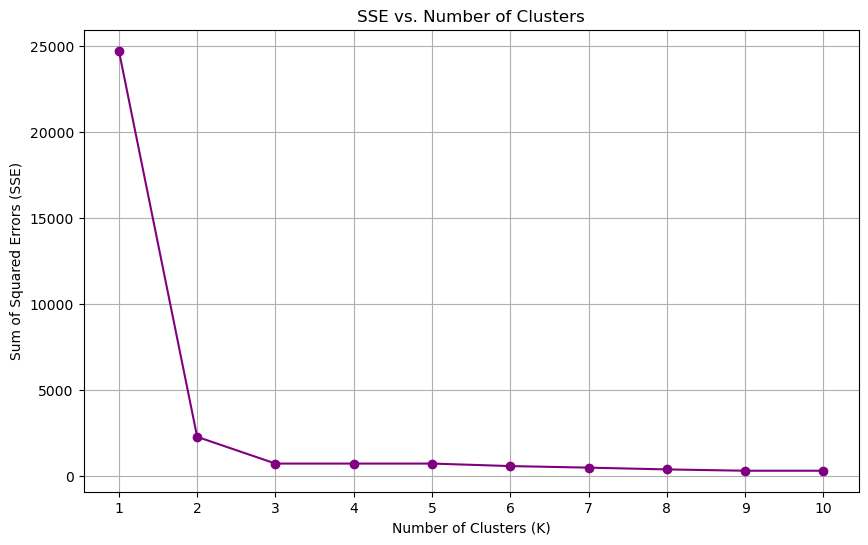

In [317]:
K = [i for i in range(1,11)]
sse = []
for k in K:
    model = KMeans(k = k, return_sse = True)
    sse.append(model.fit_predict(data_iris))
    
plot_sse(sse, K)

# Make cluster assignments for Iris data

In [321]:
# Initialize KMeans class with k = 3 and get the clusters
# Write the clusters to .txt file and upload the file to miner
kmeans = KMeans(k = 3, return_sse = False)
a = kmeans.fit_predict(data_iris)
with open("outputiris.txt", "w") as file:
    for i in a:
        file.write(str(i) + "\n")

[[ 1.36172719  4.85638285]
 [13.65075854  0.36066745]
 [-6.15089997 -5.29210429]]


# Objective function vs K for Image data

[[-18.60411292  58.99412191]
 [ 30.36492547   9.9591213 ]]
[[-18.60411292  58.99412191]
 [ 30.36492547   9.9591213 ]
 [-48.54025005 -51.69595261]
 [-61.95676388  47.21948704]]
[[-18.60411292  58.99412191]
 [ 30.36492547   9.9591213 ]
 [-48.54025005 -51.69595261]
 [-61.95676388  47.21948704]
 [ 12.43529389  25.19852314]
 [-67.09391901  61.66771381]]
[[-18.60411292  58.99412191]
 [ 30.36492547   9.9591213 ]
 [-48.54025005 -51.69595261]
 [-61.95676388  47.21948704]
 [ 12.43529389  25.19852314]
 [-67.09391901  61.66771381]
 [ 44.12579717 -43.84817153]
 [-45.00493745 -47.87823744]]
[[-18.60411292  58.99412191]
 [ 30.36492547   9.9591213 ]
 [-48.54025005 -51.69595261]
 [-61.95676388  47.21948704]
 [ 12.43529389  25.19852314]
 [-67.09391901  61.66771381]
 [ 44.12579717 -43.84817153]
 [-45.00493745 -47.87823744]
 [-28.23450197  -0.33409632]
 [-10.73998457 -32.86021904]]
[[-18.60411292  58.99412191]
 [ 30.36492547   9.9591213 ]
 [-48.54025005 -51.69595261]
 [-61.95676388  47.21948704]
 [ 12.435

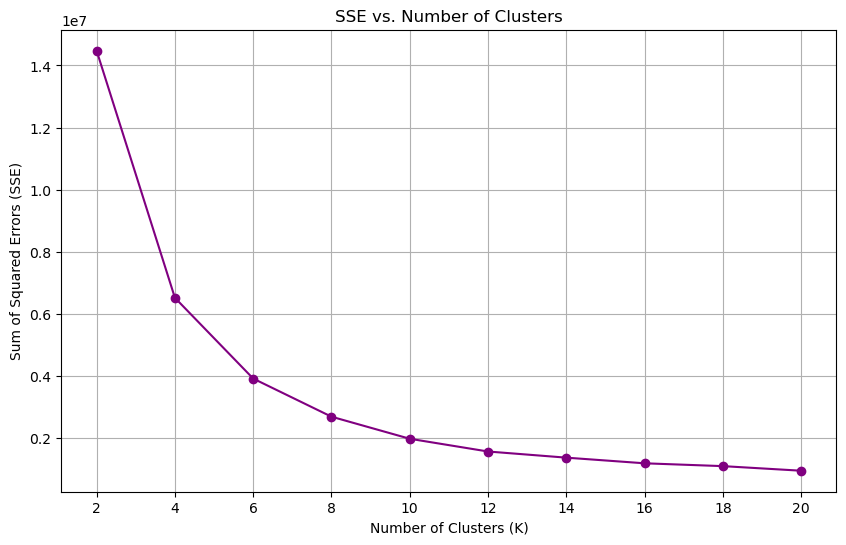

In [318]:
K = [i for i in range(2,21, 2)]
sse = []
for k in K:
    model = KMeans(k = k, return_sse = True)
    sse.append(model.fit_predict(data_images))

plot_sse(sse, K)

# Make cluster assignments for Image data

In [320]:
# Initialize KMeans class with k = 10 and get the clusters
# Write the clusters to .txt file and upload the file to miner
kmeans = KMeans(k = 10, return_sse = False)
a = kmeans.fit_predict(data_images)
with open("outputimages.txt", "w") as file:
    for i in a:
        file.write(str(i) + "\n")

[[-18.60411292  58.99412191]
 [ 30.36492547   9.9591213 ]
 [-48.54025005 -51.69595261]
 [-61.95676388  47.21948704]
 [ 12.43529389  25.19852314]
 [-67.09391901  61.66771381]
 [ 44.12579717 -43.84817153]
 [-45.00493745 -47.87823744]
 [-28.23450197  -0.33409632]
 [-10.73998457 -32.86021904]]
